# UKCI Threshold Detector

Detects extreme and compound events across UKCI (UKCP for now) data for a chosen UK region. The ensemble gives a **range of projections** rather than a single answer, reflecting model uncertainty.Single ensemble members shouldn't be taken as truth, all members represent equally (is equally correct?) plausible projections. For this reason, ensemble means aren't a realistic 'middle of the road' projection of future climate change, as it can wash out variability. Further, not all members needs to agree on a trend for it to be considered valid, even a couple of members exhibiting a behaviour change (e.g.: increase in drought conditions by 2040) can be considered a significant likelihood of occuring. 

## What to do

**You only need to edit Cell 2.** All other cells run automatically from those settings. Work through the cells in order (Run All, or Shift+Enter cell by cell).

## Detection modes

The notebook supports three modes, controlled by the parameters in Cell 2:

| Mode | When to use | Key settings |
|---|---|---|
| **Single-variable** | One variable, one threshold | Set `THRESHOLD_2 = None` |
| **Bivariate: sequential** | Two variables that occur within a few days of each other (e.g. a dry spell *followed by* extreme rainfall) | Set `THRESHOLD_2`, `COMPOUND_MODE = 'sequential'` |
| **Bivariate: co-occurring** | Two variables that are simultaneously extreme (e.g. a heat extreme *during* a drought) | Set `THRESHOLD_2`, `COMPOUND_MODE = 'co-occurring'` |

In **sequential** mode a compound event is a cluster of extreme days drawn from *either* variable, where no two consecutive extreme days (from either series) are more than `DELT` days apart, and the cluster contains at least one extreme day from *each* variable.

In **co-occurring** mode a compound event requires at least one day where *both* variables are simultaneously extreme. Adjacent coincident days within `DELT` of each other are merged into a single event.

---

## Parameter reference

### Data sources
| Parameter | Description |
|---|---|
| `BASE_DIR` | Root directory that contains per-region sub-folders for **Variable 1**. |
| `FILENAME_PATTERN` | Filename template for Variable 1. Use `{ensemble}` and `{region}` as placeholders, e.g. `'p110{ensemble}_{region}.nc'`. |
| `BASE_DIR_2` | Root directory for **Variable 2**. Set to `None` to load both variables from the same files as Variable 1. |
| `FILENAME_PATTERN_2` | Filename template for Variable 2. Set to `None` to use the same template as Variable 1. |

### Domain
| Parameter | Description |
|---|---|
| `REGION` | The UK region to analyse in Steps 2–4. Must match a sub-folder name inside `BASE_DIR`. |
| `ENSEMBLES` | List of ensemble member IDs to process. |
| `ALL_REGIONS` | Full list of UK regions used in the UK-wide (Step 5) and regional (Step 6) plots. |

### Season
| Parameter | Description |
|---|---|
| `LOWER_MONTH` | First month of the season to extract (inclusive, 1–12). |
| `HIGHER_MONTH` | Last month of the season to extract (inclusive, 1–12). Default `6–9` = JJAS (summer). |

### Variable 1 — threshold
| Parameter | Description |
|---|---|
| `THRESHOLD` | The threshold value that defines an extreme event for Variable 1. Units should match the data (e.g. mm/hr, °C). |
| `DIRECTION` | `'above'` flags values *greater than* the threshold (e.g. heavy rain, heat). `'below'` flags values *less than* the threshold (e.g. drought, cold). |
| `N_CONSECUTIVE` | Number of consecutive days that must exceed the threshold to constitute a flagged event. `1` means any single exceedance counts. Increase this for events like prolonged dry spells. |

### Variable 2 — threshold (bivariate only)
These work identically to the Variable 1 settings above, but are applied to the second timeseries. Set `THRESHOLD_2 = None` to run in single-variable mode.

| Parameter | Description |
|---|---|
| `THRESHOLD_2` | Threshold for Variable 2. `None` disables bivariate detection. |
| `DIRECTION_2` | `'above'` or `'below'`, as above. |
| `N_CONSECUTIVE_2` | Consecutive days required for Variable 2. |

### Compound detection
These settings apply to all three modes.

| Parameter | Description |
|---|---|
| `COMPOUND_MODE` | `'sequential'` or `'co-occurring'`. Only relevant when `THRESHOLD_2` is set. |
| `DELT` | Maximum gap in days between consecutive extreme days (from either variable in bivariate mode) that still allows them to be grouped into a single compound event. Larger values merge more spread-out clusters. |
| `MIN_DURATION` | Minimum number of extreme days required for a cluster to be counted as a compound event. Filters out isolated single-day spikes (single-variable) or single co-occurrence days (bivariate). |
| `TAU` | Coincidence interval (days) used in Event Coincidence Analysis (Step not shown by default). Two events coincide if they fall within `tau` days of each other. |

### Plotting
| Parameter | Description |
|---|---|
| `CMAP` | Matplotlib colormap name used in the Hovmöller plots (e.g. `'Blues'`, `'YlOrRd'`). More examples here: https://matplotlib.org/stable/users/explain/colors/colormaps.html |
| `ROLLING_WINDOW` | Window size (years) for the rolling mean in the ensemble-spread plot (Step 3). |
| `DATA_START_YEAR` | Calendar year that index 0 of the loaded timeseries corresponds to. Used to assign a `year` label to each detected event. |

---

## Output

Each step produces a different view of the same compound-event signal:

- **Step 1** — loads the raw timeseries for every ensemble member.
- **Step 2** — flags extreme days and detects compound events for every member.
- **Step 3** — plots the ensemble *spread* (mean ± min/max band) of compound-event counts per year.
- **Step 4** — Hovmöller plot: every ensemble member × every year for the chosen region.
- **Step 5** — UK-wide Hovmöller: a day is counted if *any* region had a compound event on that day.
- **Step 6** — Regional Hovmöller: ensemble-mean compound extreme days per region per year.


In [13]:

# ============================================================
# USER PARAMETERS — edit this cell only
# ============================================================

# --- Data sources ---
# Configure file paths for both variables here.
# Variable 2 defaults to None, which means it re-uses Variable 1's values.
BASE_DIR           = '/home/users/elena.dauster/Documents/python/CoinCalc/data_for_ECA'
FILENAME_PATTERN   = 'p110{ensemble}_{region}.nc'    # Variable 1 filename template
BASE_DIR_2         = None    # e.g. '/path/to/temperature/data' — None = same as BASE_DIR
FILENAME_PATTERN_2 = None    # e.g. 'tasmax{ensemble}_{region}.nc' — None = same as FILENAME_PATTERN

REGION = 'Wales'   # choose one region

ENSEMBLES = ['0000','1113','1554','1649','1843','1935','2123','2242','2305','2335','2491','2868']

# All UK regions (used for the UK-wide Hovmöller in Step 5)
ALL_REGIONS = [
    'East_Midlands', 'East_Scotland', 'East_of_England', 'North_East_England',
    'North_Scotland', 'North_West_England', 'Northern_Ireland', 'South_East_England',
    'South_West_England', 'Wales', 'West_Midlands', 'West_Scotland', 'Yorkshire_and_Humber',]

# --- Season ---
LOWER_MONTH = 6
HIGHER_MONTH = 9

# --- Threshold (Variable 1) ---
THRESHOLD     = 1          # threshold for event detection
DIRECTION     = 'below'     # 'above' or 'below' the threshold
N_CONSECUTIVE = 1           # consecutive days required to flag an event

# --- Variable 2 (optional — set THRESHOLD_2 = None for single-variable mode) ---
# A compound event requires at least one extreme from EACH variable.
# File paths for Variable 2 are set above (BASE_DIR_2 / FILENAME_PATTERN_2).
THRESHOLD_2     = 1      # set to None to disable bivariate detection
DIRECTION_2     = 'below'   # 'above' or 'below'
N_CONSECUTIVE_2 = 20        # consecutive days for variable 2

# --- Compound mode (bivariate only) ---
# 'sequential'   : extremes from both variables within DELT days of each other
#                  (e.g. dry spell then extreme rain; works with same or different files)
# 'co-occurring' : both variables extreme on the same day(s)
#                  (e.g. heat + drought; works with same or different files)
COMPOUND_MODE = 'sequential'

# --- Compound detection ---
DELT         = 1            # max gap (days) between extremes to form one compound event
MIN_DURATION = 20            # minimum number of extreme days to count as a compound event
TAU = 1                     # number of days to shift the second variable relative to the first (for sequential events)

# --- Plotting ---
CMAP           = 'Reds'
ROLLING_WINDOW = 6

# Years your data spans (for the year column)
DATA_START_YEAR = 1980

# ============================================================
if THRESHOLD_2 is None:
    _mode = "single-variable"
else:
    _mode = f"bivariate ({COMPOUND_MODE})"
print(f"Region: {REGION} | {len(ENSEMBLES)} ensemble members | {len(ALL_REGIONS)} UK regions | mode: {_mode}")


Region: Wales | 12 ensemble members | 13 UK regions | mode: bivariate (sequential)


In [14]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

from threshold_detector import (
    flag_extreme_events,
    detect_compound_events,
    detect_compound_events_bivariate,
    detect_compound_events_coincident,
    load_region_ensemble,
    summarise_ensemble_events,
    run_eca,
    plot_ensemble_spread,
    plot_ensemble_hovmoller,
    plot_duration_and_counts,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Imports successful.")


Imports successful.


## Step 1: Load all ensemble members for the region

In [15]:
ensemble_data = load_region_ensemble(
    base_dir=BASE_DIR,
    region=REGION,
    ensembles=ENSEMBLES,
    lower_month=LOWER_MONTH,
    higher_month=HIGHER_MONTH,
    filename_pattern=FILENAME_PATTERN,
)

print(f"Loaded {len(ensemble_data)} members for {REGION}.")
for ens, arr in ensemble_data.items():
    print(f"  {ens}: {len(arr)} days")

# Load Variable 2 separately only if its source differs from Variable 1.
# Otherwise both variables are derived from the same timeseries.
if THRESHOLD_2 is not None and (BASE_DIR_2 is not None or FILENAME_PATTERN_2 is not None):
    ensemble_data_2 = load_region_ensemble(
        base_dir=BASE_DIR_2 or BASE_DIR,
        region=REGION,
        ensembles=ENSEMBLES,
        lower_month=LOWER_MONTH,
        higher_month=HIGHER_MONTH,
        filename_pattern=FILENAME_PATTERN_2 or FILENAME_PATTERN,
    )
    print(f"\nLoaded Variable 2 for {len(ensemble_data_2)} members.")
else:
    ensemble_data_2 = ensemble_data


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


Loaded 12 members for Wales.
  0000: 12000 days
  1113: 12000 days
  1554: 12000 days
  1649: 12000 days
  1843: 12000 days
  1935: 12000 days
  2123: 12000 days
  2242: 12000 days
  2305: 12000 days
  2335: 12000 days
  2491: 12000 days
  2868: 12000 days


## Step 2: Detect extremes and compound events for every member

Each member is processed independently, then collected together so we can
see the ensemble range.

In [16]:
events_by_member = {}
days_per_member = len(next(iter(ensemble_data.values())))
days_per_year = days_per_member // (2079 - DATA_START_YEAR + 1)  # approx JJAS days/yr

for ensemble, data in ensemble_data.items():
    binary_1 = flag_extreme_events(
        data, threshold=THRESHOLD, direction=DIRECTION, N=N_CONSECUTIVE)
    if THRESHOLD_2 is not None:
        data_2 = ensemble_data_2.get(ensemble, data)
        binary_2 = flag_extreme_events(
            data_2, threshold=THRESHOLD_2, direction=DIRECTION_2, N=N_CONSECUTIVE_2)
        if COMPOUND_MODE == 'co-occurring':
            events = detect_compound_events_coincident(
                binary_1, binary_2, delT=DELT, min_duration=MIN_DURATION)
        else:
            events = detect_compound_events_bivariate(
                binary_1, binary_2, delT=DELT, min_duration=MIN_DURATION)
    else:
        events = detect_compound_events(binary_1, delT=DELT, min_duration=MIN_DURATION)

    # Attach a year column from the index
    if len(events) > 0:
        events['year'] = DATA_START_YEAR + (events['start_idx'] // days_per_year).astype(int)
        events['ensemble'] = ensemble
    events_by_member[ensemble] = events

    print(f"  {ensemble}: {len(events)} compound events")

# Combine into one long DataFrame for plotting functions that need it
all_events = pd.concat(
    [df for df in events_by_member.values() if len(df) > 0],
    ignore_index=True)
print(f"\nTotal compound events across ensemble: {len(all_events)}")


  0000: 7 compound events
  1113: 2 compound events
  1554: 4 compound events
  1649: 6 compound events
  1843: 5 compound events
  1935: 1 compound events
  2123: 5 compound events
  2242: 1 compound events
  2305: 1 compound events
  2335: 7 compound events
  2491: 5 compound events
  2868: 3 compound events

Total compound events across ensemble: 47


## Step 3: Ensemble spread — the projection range

This is the key PPE output: the mean projection with the min–max band
across all members.

   year      mean  min  max  median  n_members
0  1981  0.083333  0.0  1.0     0.0          1
1  1988  0.083333  0.0  1.0     0.0          1
2  1991  0.166667  0.0  1.0     0.0          2
3  1992  0.083333  0.0  1.0     0.0          1
4  1993  0.083333  0.0  1.0     0.0          1


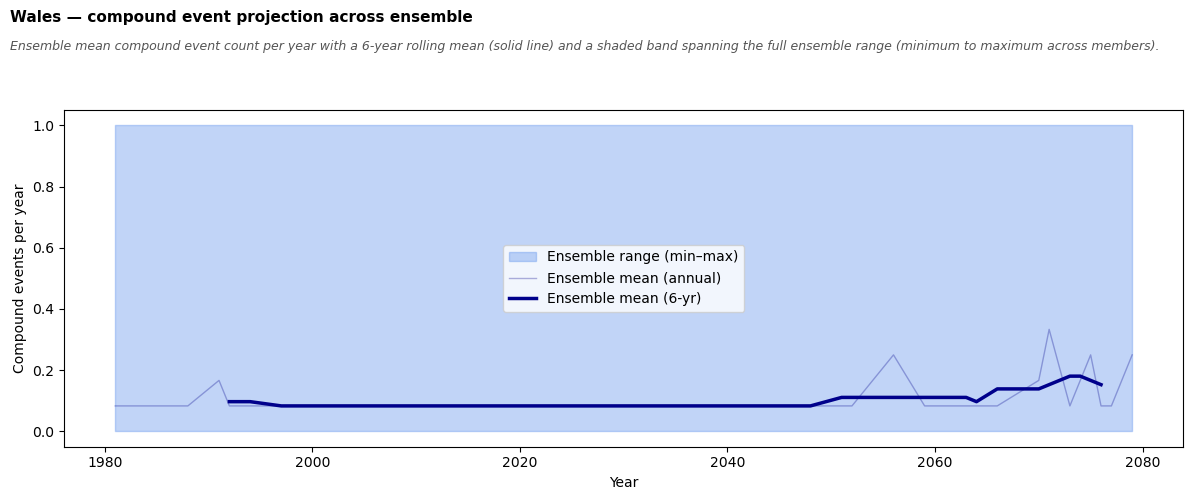

In [17]:
summary = summarise_ensemble_events(events_by_member)
print(summary.head())

fig = plot_ensemble_spread(
    summary,
    rolling_window=ROLLING_WINDOW,
    title=f'{REGION} — compound event projection across ensemble')

#fig.savefig(f'../outputs/figures/{REGION}_ensemble_spread.png',dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Hovmöller — every member over time

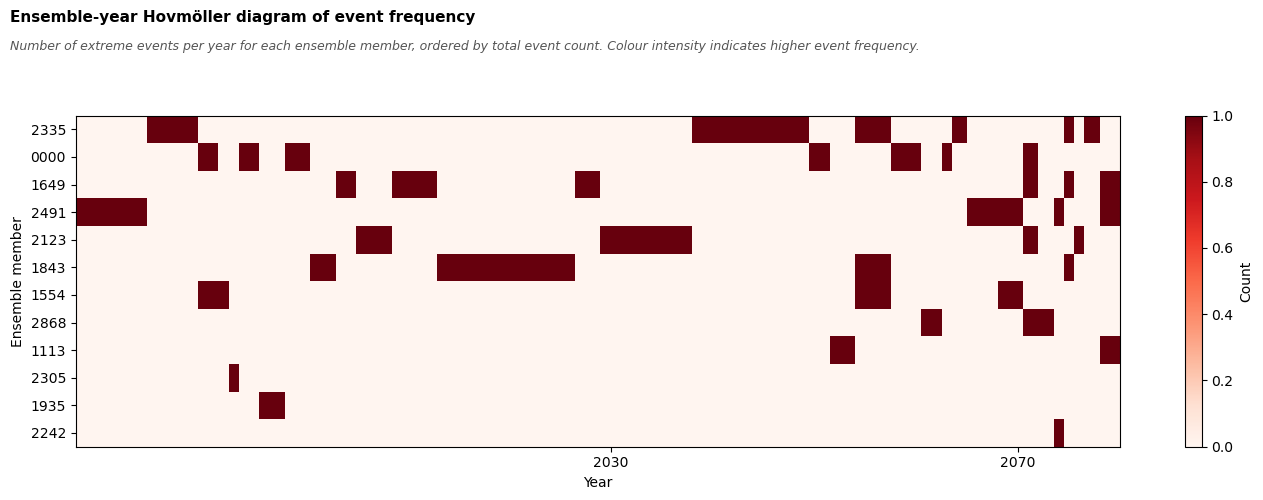

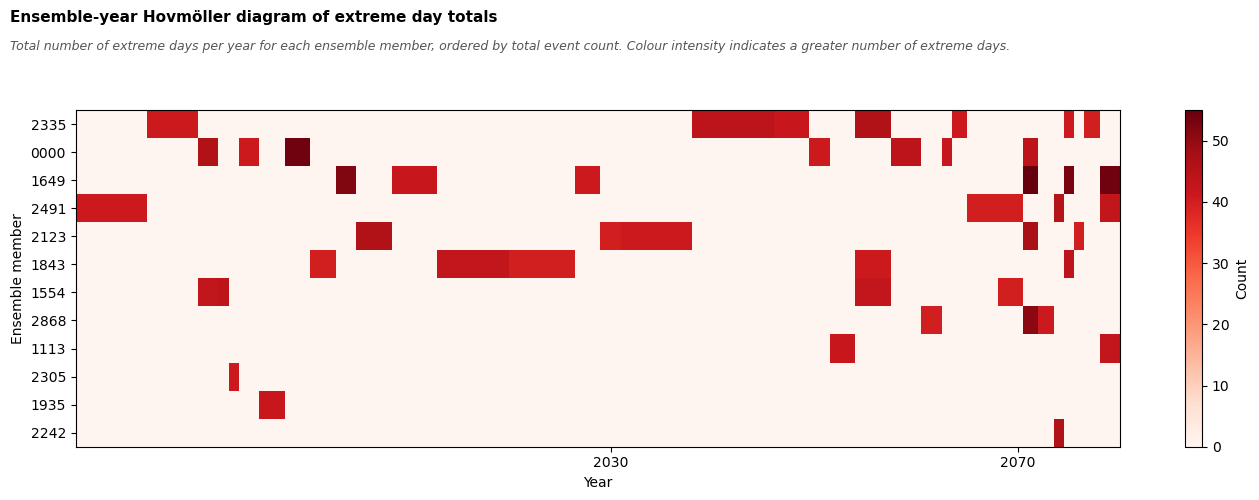

In [18]:
fig_events, fig_days = plot_ensemble_hovmoller(
    all_events,
    ensemble_col='ensemble',
    year_col='year',
    extreme_days_col='n_extreme_days',
    cmap=CMAP,)
fig_events.savefig(f'../outputs/figures/{REGION}_hovmoller_events.png',
                   dpi=150, bbox_inches='tight')
fig_days.savefig(f'../outputs/figures/{REGION}_hovmoller_days.png',
                 dpi=150, bbox_inches='tight')
plt.show()

## Step 5: UK-wide Hovmöller — union across all regions

A day is counted as extreme if **any** UK region exceeded the threshold.
This matches the all-UK aggregated CSV used in `timeseries.ipynb`.

In [ ]:
uk_events_by_member = {}

for ensemble in ENSEMBLES:
    compound_idx_union = set()
    days_per_year_uk = None

    for region in ALL_REGIONS:
        try:
            region_data = load_region_ensemble(
                base_dir=BASE_DIR, region=region,
                ensembles=[ensemble],
                lower_month=LOWER_MONTH, higher_month=HIGHER_MONTH,
                filename_pattern=FILENAME_PATTERN,
            )[ensemble]
            if days_per_year_uk is None:
                days_per_year_uk = len(region_data) // (2079 - DATA_START_YEAR + 1)

            binary_1 = flag_extreme_events(
                region_data, threshold=THRESHOLD, direction=DIRECTION, N=N_CONSECUTIVE
            )

            if THRESHOLD_2 is not None:
                if BASE_DIR_2 is not None or FILENAME_PATTERN_2 is not None:
                    region_data_2 = load_region_ensemble(
                        base_dir=BASE_DIR_2 or BASE_DIR, region=region,
                        ensembles=[ensemble],
                        lower_month=LOWER_MONTH, higher_month=HIGHER_MONTH,
                        filename_pattern=FILENAME_PATTERN_2 or FILENAME_PATTERN,
                    ).get(ensemble, region_data)
                else:
                    region_data_2 = region_data

                binary_2 = flag_extreme_events(
                    region_data_2, threshold=THRESHOLD_2, direction=DIRECTION_2, N=N_CONSECUTIVE_2
                )
                if COMPOUND_MODE == 'co-occurring':
                    region_events = detect_compound_events_coincident(
                        binary_1, binary_2, delT=DELT, min_duration=MIN_DURATION
                    )
                    binary_arr = ((np.array(binary_1, dtype=int) == 1) &
                                  (np.array(binary_2, dtype=int) == 1)).astype(int)
                else:
                    region_events = detect_compound_events_bivariate(
                        binary_1, binary_2, delT=DELT, min_duration=MIN_DURATION
                    )
                    binary_arr = np.clip(
                        np.array(binary_1, dtype=int) + np.array(binary_2, dtype=int), 0, 1
                    )
            else:
                region_events = detect_compound_events(binary_1, delT=DELT, min_duration=MIN_DURATION)
                binary_arr = np.array(binary_1, dtype=int)

            for _, row in region_events.iterrows():
                for idx in range(int(row['start_idx']), int(row['end_idx']) + 1):
                    if binary_arr[idx] == 1:
                        compound_idx_union.add(idx)
        except Exception as e:
            print(f"  Warning: could not load {region} for {ensemble}: {e}")
            continue

    if not compound_idx_union or days_per_year_uk is None:
        uk_events_by_member[ensemble] = pd.DataFrame(
            columns=['start_idx', 'end_idx', 'length', 'n_extreme_days', 'year', 'ensemble'])
        continue

    n_days = days_per_year_uk * (2079 - DATA_START_YEAR + 1)
    union_compound_binary = np.zeros(n_days, dtype=int)
    for idx in compound_idx_union:
        if idx < n_days:
            union_compound_binary[idx] = 1

    events = detect_compound_events(union_compound_binary, delT=DELT, min_duration=MIN_DURATION)

    if len(events) > 0:
        events['year'] = DATA_START_YEAR + (events['start_idx'] // days_per_year_uk).astype(int)
        events['ensemble'] = ensemble
    uk_events_by_member[ensemble] = events
    print(f"  {ensemble}: {len(events)} UK-wide compound events")

uk_all_events = pd.concat(
    [df for df in uk_events_by_member.values() if len(df) > 0],
    ignore_index=True)

print(f"\nTotal UK-wide compound events across ensemble: {len(uk_all_events)}")


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


  0000: 170 UK-wide compound events


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


  1113: 234 UK-wide compound events


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


...

  2335: 61 UK-wide compound events


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


  2491: 197 UK-wide compound events


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


  2868: 251 UK-wide compound events

Total UK-wide compound events across ensemble: 1992


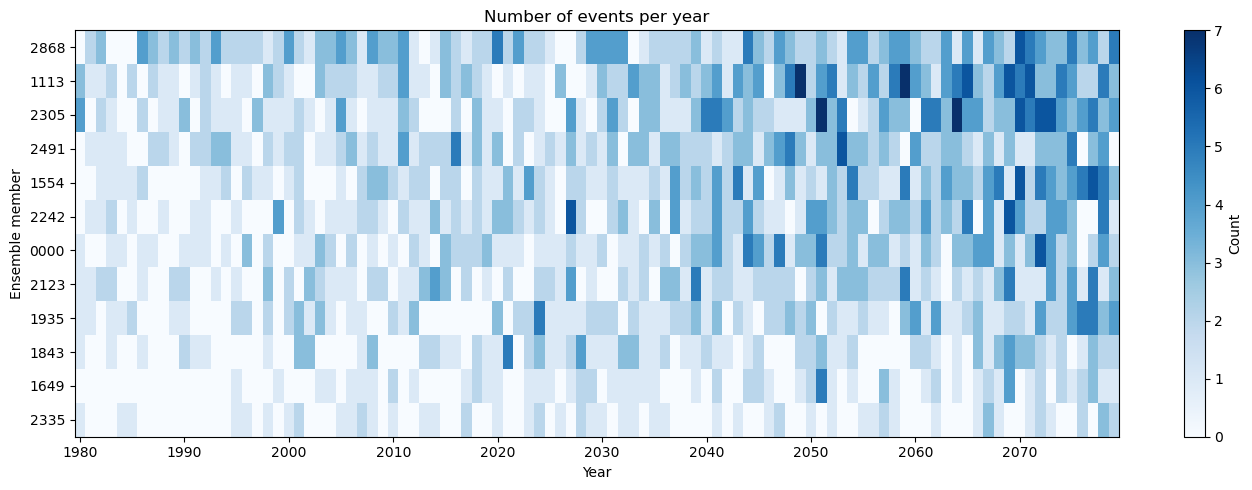

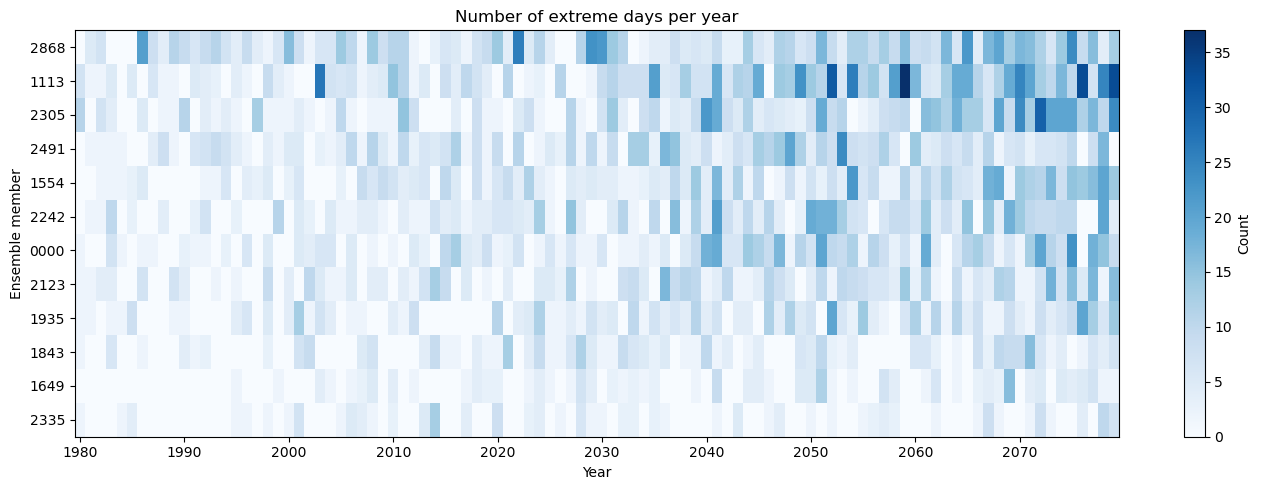

In [13]:
fig_uk_events, fig_uk_days = plot_ensemble_hovmoller(
    uk_all_events,
    ensemble_col='ensemble',
    year_col='year',
    extreme_days_col='n_extreme_days',
    cmap=CMAP,)
fig_uk_events.savefig('../outputs/figures/UK_wide_hovmoller_events.png',
                      dpi=150, bbox_inches='tight')
fig_uk_days.savefig('../outputs/figures/UK_wide_hovmoller_days.png',
                    dpi=150, bbox_inches='tight')
plt.show()


## Step 6: Regional Hovmöller — compound days per region per year

Each row is a UK region; colour shows the ensemble-mean number of
extreme days in compound events for that region per year.

/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/common/mixin.py:212: FutureWarning: You are usi

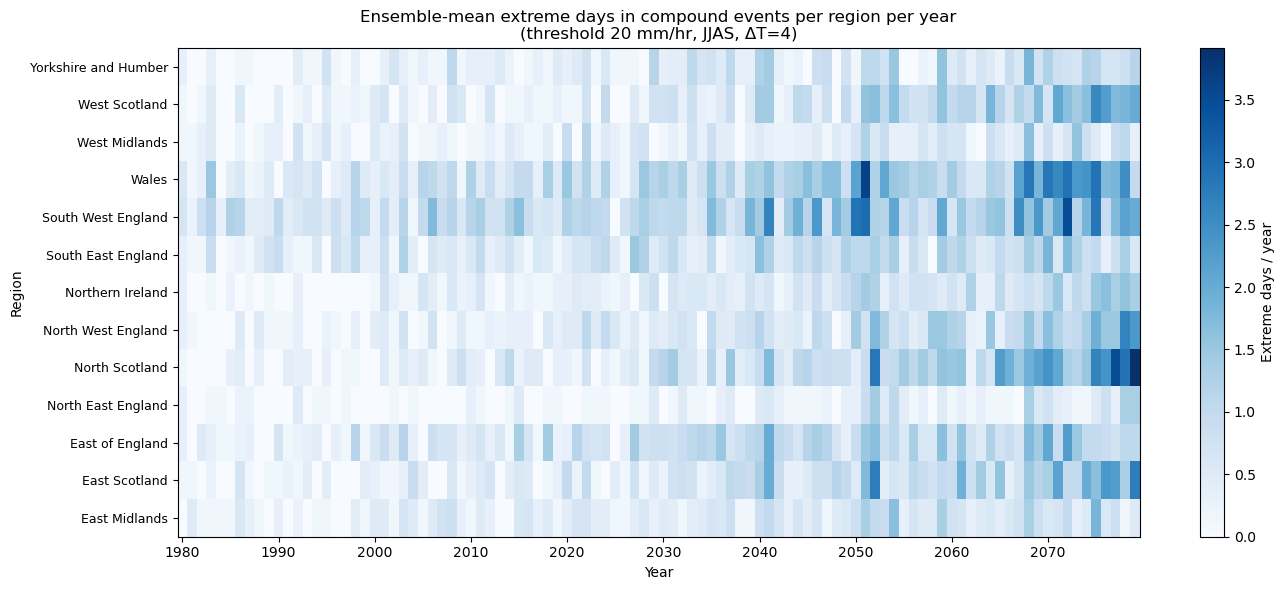

In [ ]:
# For each region, compute ensemble-mean extreme days in compound events per year
region_year_matrix = {}

for region in ALL_REGIONS:
    member_counts = {}
    for ensemble in ENSEMBLES:
        try:
            region_data = load_region_ensemble(
                base_dir=BASE_DIR, region=region,
                ensembles=[ensemble],
                lower_month=LOWER_MONTH, higher_month=HIGHER_MONTH,
                filename_pattern=FILENAME_PATTERN,
            )[ensemble]
            binary_1 = flag_extreme_events(
                region_data, threshold=THRESHOLD, direction=DIRECTION, N=N_CONSECUTIVE
            )
            if THRESHOLD_2 is not None:
                if BASE_DIR_2 is not None or FILENAME_PATTERN_2 is not None:
                    region_data_2 = load_region_ensemble(
                        base_dir=BASE_DIR_2 or BASE_DIR, region=region,
                        ensembles=[ensemble],
                        lower_month=LOWER_MONTH, higher_month=HIGHER_MONTH,
                        filename_pattern=FILENAME_PATTERN_2 or FILENAME_PATTERN,
                    ).get(ensemble, region_data)
                else:
                    region_data_2 = region_data

                binary_2 = flag_extreme_events(
                    region_data_2, threshold=THRESHOLD_2, direction=DIRECTION_2, N=N_CONSECUTIVE_2
                )
                if COMPOUND_MODE == 'co-occurring':
                    events = detect_compound_events_coincident(
                        binary_1, binary_2, delT=DELT, min_duration=MIN_DURATION
                    )
                else:
                    events = detect_compound_events_bivariate(
                        binary_1, binary_2, delT=DELT, min_duration=MIN_DURATION
                    )
            else:
                events = detect_compound_events(binary_1, delT=DELT, min_duration=MIN_DURATION)

            if len(events) > 0:
                days_per_year_r = len(region_data) // (2079 - DATA_START_YEAR + 1)
                events['year'] = DATA_START_YEAR + (events['start_idx'] // days_per_year_r).astype(int)
                member_counts[ensemble] = events.groupby('year')['n_extreme_days'].sum()
        except Exception as e:
            print(f"  Warning: {region} / {ensemble}: {e}")
            continue

    if member_counts:
        counts_table = pd.DataFrame(member_counts).fillna(0)
        region_year_matrix[region] = counts_table.mean(axis=1)  # ensemble mean

all_years_reg = sorted({yr for s in region_year_matrix.values() for yr in s.index})
regions_sorted = sorted(region_year_matrix.keys())

hov = np.zeros((len(regions_sorted), len(all_years_reg)))
for i, region in enumerate(regions_sorted):
    for j, yr in enumerate(all_years_reg):
        hov[i, j] = region_year_matrix[region].get(yr, 0)

fig, ax = plt.subplots(figsize=(14, 6))
c = ax.pcolormesh(all_years_reg, np.arange(len(regions_sorted)), hov,
                  shading='nearest', cmap=CMAP)
ax.set_yticks(np.arange(len(regions_sorted)))
ax.set_yticklabels([r.replace('_', ' ') for r in regions_sorted], fontsize=9)
ax.set_xticks([y for y in all_years_reg if y % 10 == 0])
ax.set_xlabel('Year')
ax.set_ylabel('Region')
ax.set_title(f'Ensemble-mean extreme days in compound events per region per year\n'
             f'(threshold {THRESHOLD}, JJAS, ΔT={DELT})')
fig.colorbar(c, ax=ax, label='Extreme days / year')
plt.tight_layout()
fig.savefig('../outputs/figures/regional_hovmoller.png', dpi=150, bbox_inches='tight')
plt.show()
